In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


In [26]:
!pip -q install ucimlrepo

from ucimlrepo import fetch_ucirepo

# Load the UCI Online Retail dataset
online_retail = fetch_ucirepo(id=352)

# Get the original transaction data
df = online_retail.data.original.copy()

# Clean column names
df.columns = df.columns.astype(str).str.strip()

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset loaded successfully!
Shape: (541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [27]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [28]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [29]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 5268


In [30]:
print("Basic Statistics:")
display(df.describe())

Basic Statistics:


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [31]:

# Remove duplicate rows
df = df.drop_duplicates()

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.upper().str.startswith('C')]

# Remove invalid quantities
df = df[df['Quantity'] > 0]

# Remove invalid prices
df = df[df['UnitPrice'] > 0]

print("Data cleaned successfully!")
print("Cleaned dataset shape:", df.shape)

Data cleaned successfully!
Cleaned dataset shape: (524878, 8)


In [32]:
print("Missing CustomerID before removal:", df['CustomerID'].isnull().sum())

df = df.dropna(subset=['CustomerID'])

print("Missing CustomerID after removal:", df['CustomerID'].isnull().sum())
print("Final dataset shape:", df.shape)

Missing CustomerID before removal: 132186
Missing CustomerID after removal: 0
Final dataset shape: (392692, 8)


In [33]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print("Revenue column created successfully!")

display(df[['Quantity', 'UnitPrice', 'Revenue']].head())

Revenue column created successfully!


,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [34]:
total_revenue = df['Revenue'].sum()

print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £8,887,208.89


In [35]:
unique_customers = df['CustomerID'].nunique()

print("Unique Customers:", unique_customers)

Unique Customers: 4338


In [36]:
unique_products = df['StockCode'].nunique()
print("Unique Products:", unique_products)

Unique Products: 3665


In [37]:
unique_transactions = df['InvoiceNo'].nunique()
print("Unique Transactions:", unique_transactions)

Unique Transactions: 18532


In [38]:
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Best-Selling Products:")
display(top_products)

Top 10 Best-Selling Products:


,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


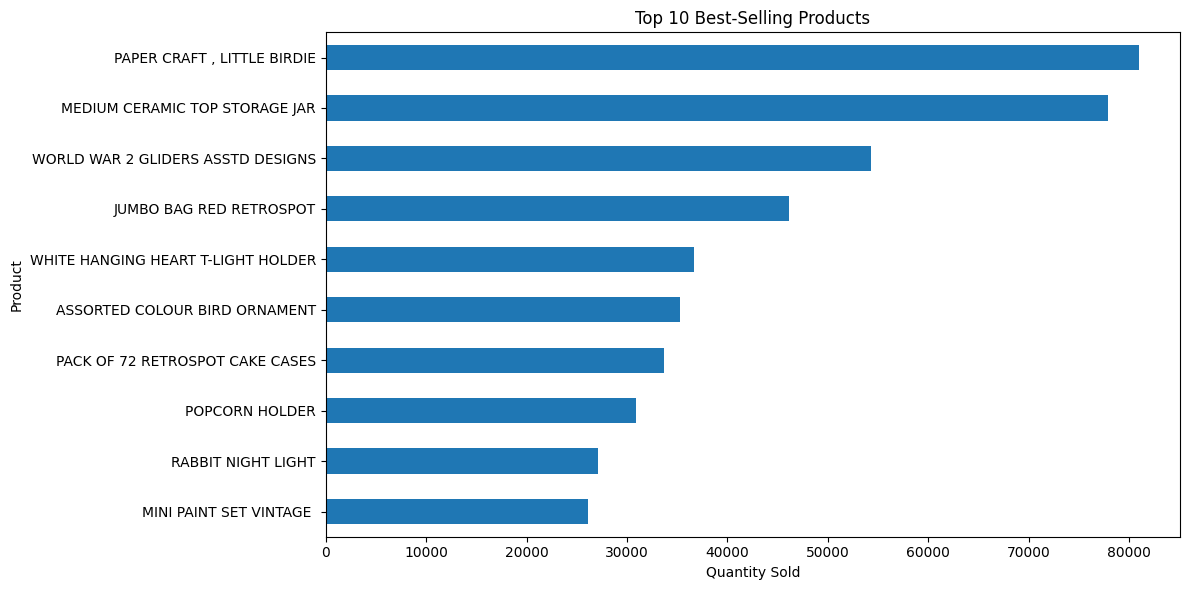

In [39]:
plt.figure(figsize=(12, 6))
top_products.sort_values().plot(kind='barh')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [40]:
product_data = df.dropna(subset=['Description']).copy()

top_revenue_products = (
    product_data.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Products by Revenue:")
display(top_revenue_products)

Top 10 Products by Revenue:


,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68785.23
ASSORTED COLOUR BIRD ORNAMENT,56413.03
Manual,53419.93


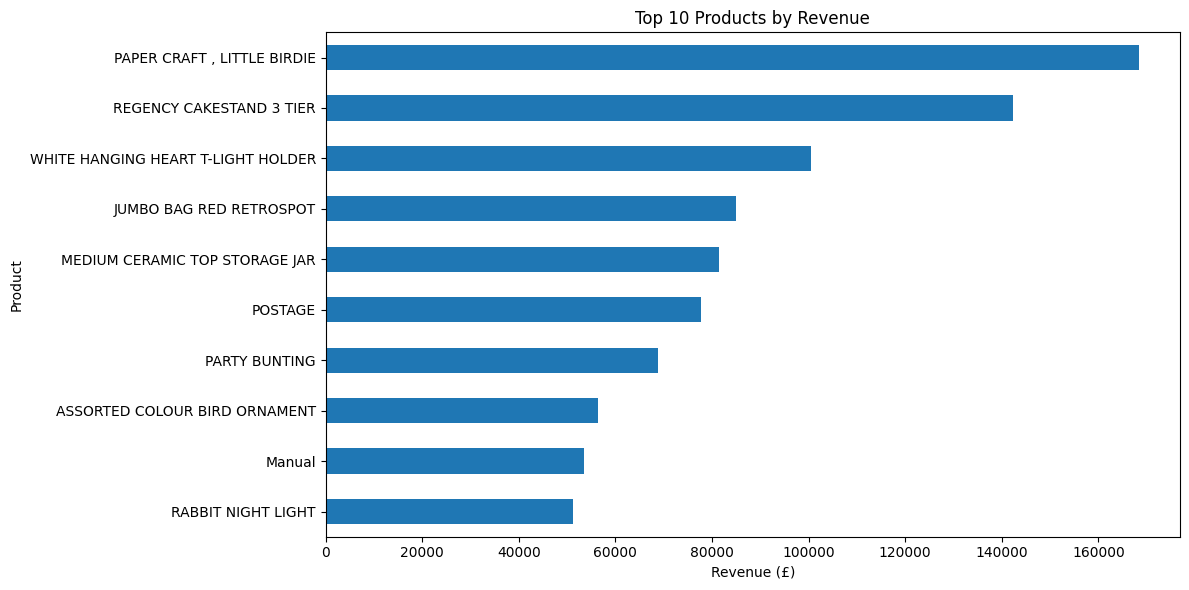

In [41]:
plt.figure(figsize=(12, 6))
top_revenue_products.sort_values().plot(kind='barh')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [42]:
df['Date'] = df['InvoiceDate'].dt.date
daily_sales = df.groupby('Date')['Revenue'].sum()

print("Daily Sales:")
display(daily_sales.head())

Daily Sales:


,Revenue
Date,
2010-12-01,46192.49
2010-12-02,47197.57
2010-12-03,23876.63
2010-12-05,31361.28
2010-12-06,31009.33


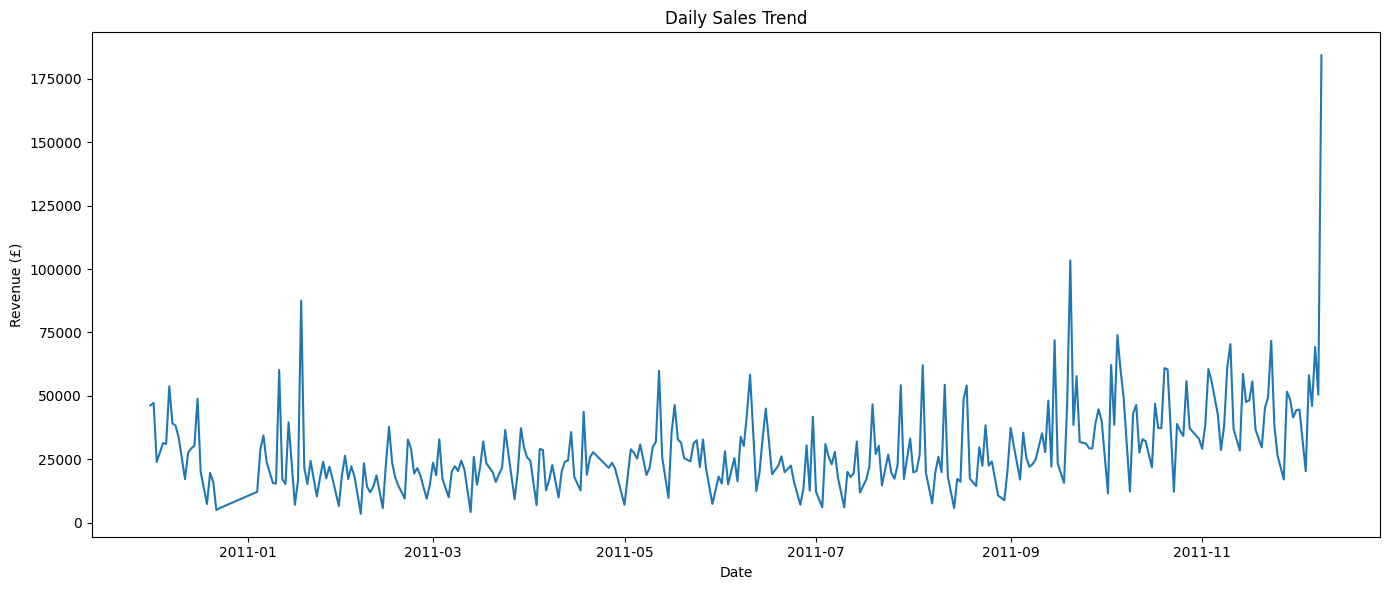

In [43]:
plt.figure(figsize=(14, 6))
daily_sales.plot()
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

In [45]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Revenue'].sum()

print("Monthly Sales:")
display(monthly_sales)

Monthly Sales:


,Revenue
Month,
2010-12,570422.730
2011-01,568101.310
2011-02,446084.920
2011-03,594081.760
2011-04,468374.331
2011-05,677355.150
2011-06,660046.050
2011-07,598962.901
2011-08,644051.040


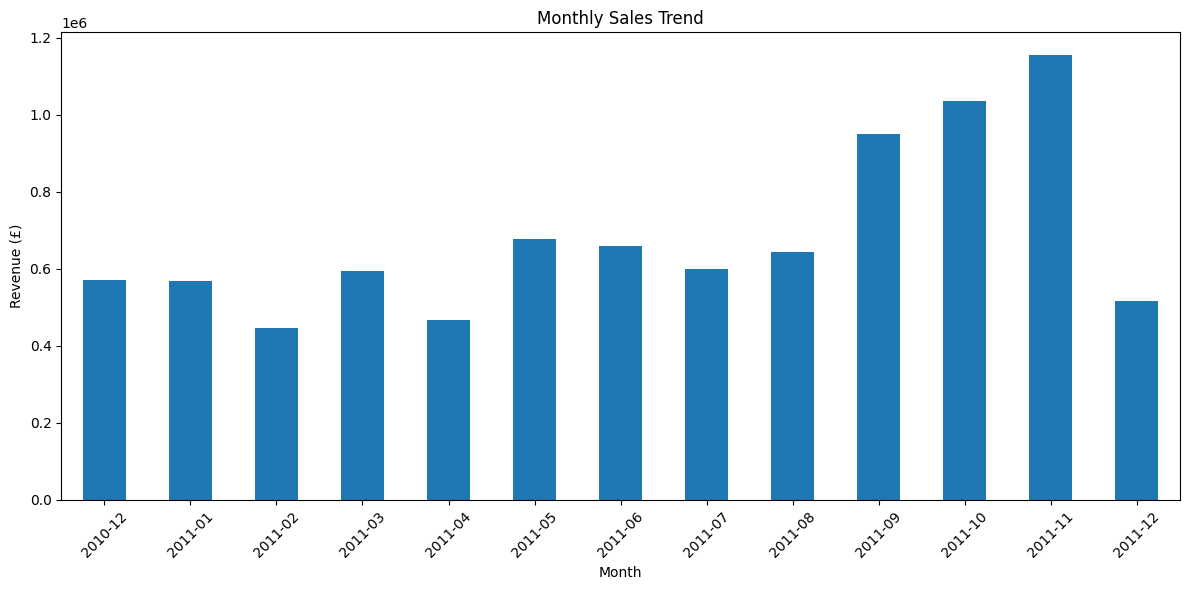

In [46]:
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='bar')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
best_month = monthly_sales.idxmax()
best_month_revenue = monthly_sales.max()

print("Best Sales Month:", best_month)
print(f"Revenue: £{best_month_revenue:,.2f}")

Best Sales Month: 2011-11
Revenue: £1,156,205.61


In [48]:
country_revenue = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 Countries by Revenue:")
display(country_revenue.head(10))

Top 10 Countries by Revenue:


,Revenue
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


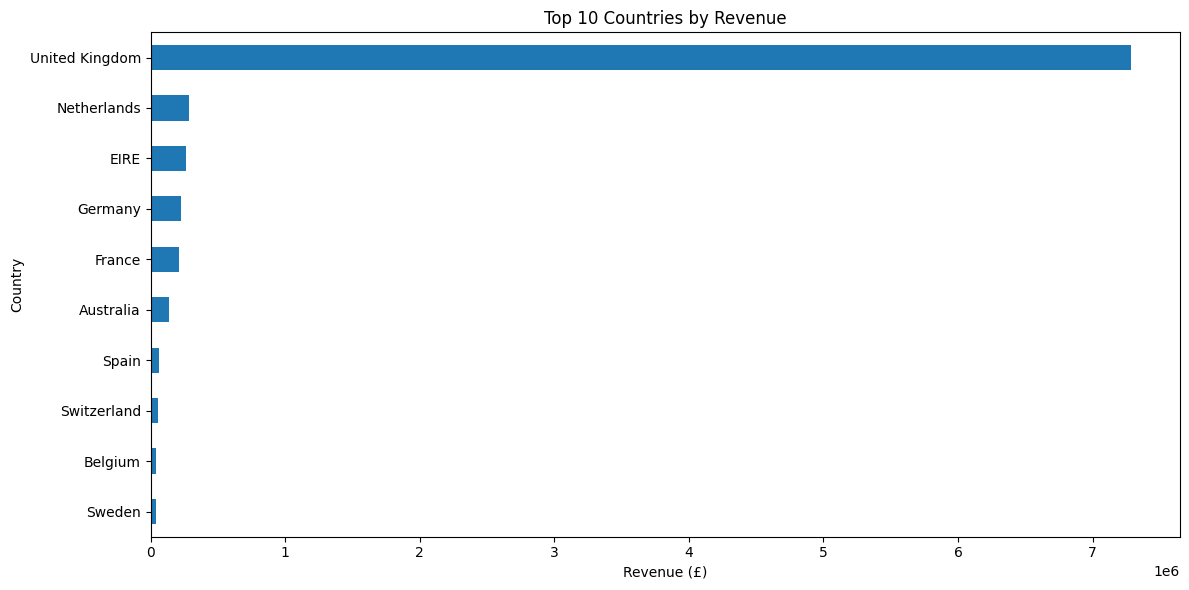

In [49]:
plt.figure(figsize=(12, 6))
country_revenue.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [50]:
customer_spending = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 Customers by Spending:")
display(customer_spending.head(10))

Top 10 Customers by Spending:


,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


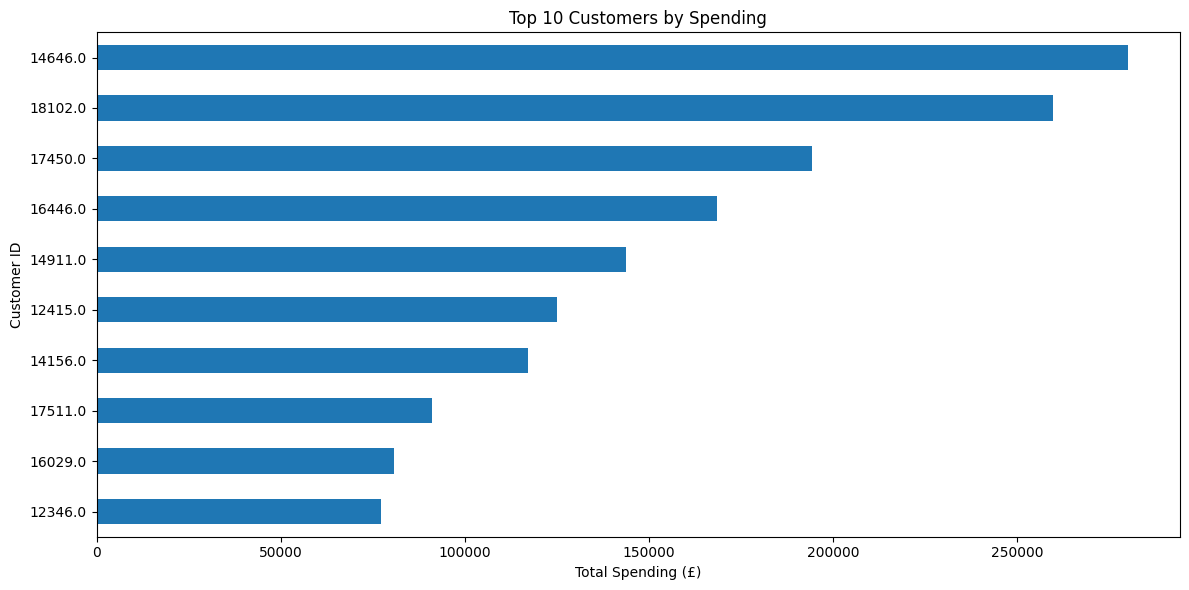

In [51]:
plt.figure(figsize=(12, 6))
customer_spending.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Customers by Spending')
plt.xlabel('Total Spending (£)')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()

In [52]:
df['CustomerSegment'] = pd.qcut(
    df['CustomerID'].map(customer_spending),
    q=4,
    labels=['Low Value', 'Medium Value', 'High Value', 'Very High Value']
)

segment_counts = df['CustomerSegment'].value_counts().sort_index()

print("Customer Segments:")
display(segment_counts)

Customer Segments:


,count
CustomerSegment,
Low Value,98229
Medium Value,98181
High Value,98127
Very High Value,98155


In [53]:
segment_revenue = df.groupby('CustomerSegment', observed=True)['Revenue'].sum()

print("Revenue by Customer Segment:")
display(segment_revenue)

Revenue by Customer Segment:


,Revenue
CustomerSegment,
Low Value,1237898.133
Medium Value,1542037.260
High Value,1737895.821
Very High Value,4369377.680


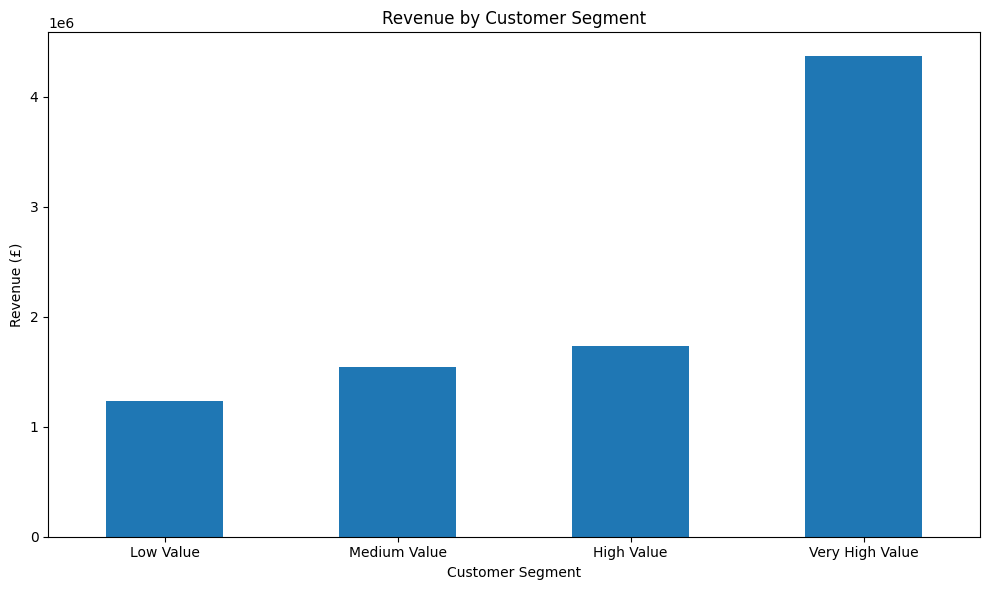

In [54]:
plt.figure(figsize=(10, 6))
segment_revenue.plot(kind='bar')
plt.title('Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [55]:
high_value_revenue = customer_spending[customer_spending >= customer_spending.quantile(0.75)]

print("Number of High-Value Customers:", len(high_value_revenue))
print(f"High-Value Customer Revenue: £{high_value_revenue.sum():,.2f}")

Number of High-Value Customers: 1085
High-Value Customer Revenue: £7,037,591.38


In [56]:
top10_revenue = top_revenue_products.sum()
total_product_revenue = df['Revenue'].sum()

print(f"Top 10 Products Revenue Share: {(top10_revenue / total_product_revenue) * 100:.2f}%")

Top 10 Products Revenue Share: 9.96%


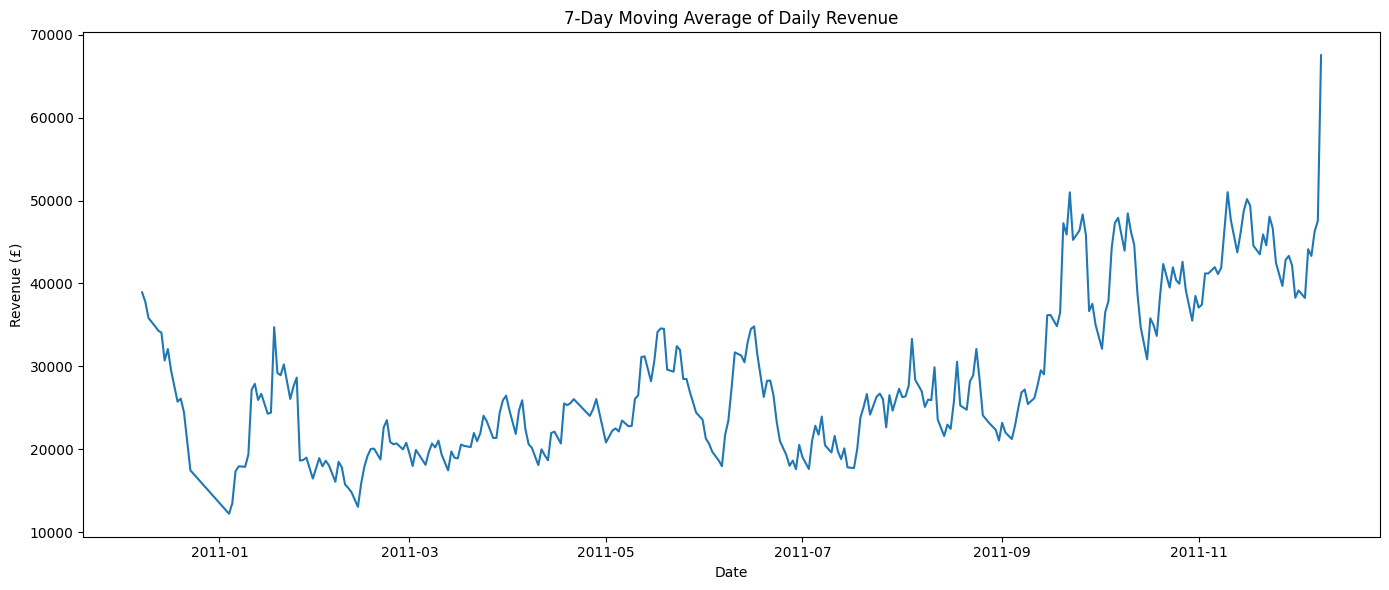

In [57]:
weekly_sales = daily_sales.rolling(7).mean()

plt.figure(figsize=(14, 6))
weekly_sales.plot()
plt.title('7-Day Moving Average of Daily Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

In [58]:
print("========== RETAIL SALES ANALYSIS SUMMARY ==========")
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Unique Products: {unique_products:,}")
print(f"Unique Transactions: {unique_transactions:,}")
print(f"Best Sales Month: {best_month}")
print(f"Best Month Revenue: £{best_month_revenue:,.2f}")
print(f"High-Value Customers: {len(high_value_revenue):,}")
print(f"Top 10 Products Revenue Share: {(top10_revenue / total_product_revenue) * 100:.2f}%")

========== RETAIL SALES ANALYSIS SUMMARY ==========
Total Revenue: £8,887,208.89
Unique Customers: 4,338
Unique Products: 3,665
Unique Transactions: 18,532
Best Sales Month: 2011-11
Best Month Revenue: £1,156,205.61
High-Value Customers: 1,085
Top 10 Products Revenue Share: 9.96%


## Key Findings

- The cleaned dataset contains 392,692 valid retail transactions.
- Total revenue generated was £8,887,208.89.
- The dataset contains 4,338 unique customers and 3,665 unique products.
- There were 18,532 unique transactions.
- November 2011 recorded the highest monthly revenue at £1,156,205.61.
- The top 10 products generated approximately 9.96% of total revenue.
- Customer segmentation identified Low Value, Medium Value, High Value, and Very High Value customer groups.
- High-value customers represent an important customer segment for targeted marketing and retention strategies.

## Business Recommendations

1. Focus on retaining high-value customers through loyalty programs and personalized offers.
2. Promote high-performing products using bundles, discounts, and cross-selling strategies.
3. Prepare additional inventory and marketing campaigns before high-sales months.
4. Monitor daily and monthly sales trends to identify seasonal demand patterns.
5. Use customer segmentation to create targeted marketing campaigns for different spending groups.
6. Analyze frequently purchased products together to identify opportunities for product bundles.

## Conclusion

This project analyzed real-world retail transaction data from the UCI Online Retail dataset. The analysis covered data cleaning, revenue calculation, product performance, customer analysis, sales trends, country-level revenue, and customer segmentation.

The results provide useful insights into customer behavior, product performance, and sales patterns that can support data-driven retail decision-making.

In [61]:
df.to_csv('retail_sales_cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")
print("File: retail_sales_cleaned.csv")

Cleaned dataset saved successfully!
File: retail_sales_cleaned.csv


In [62]:
from google.colab import files
files.download('retail_sales_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>